In [1]:
pip install kagglehub

In [2]:
import torch
from torch import nn
torch.__version__

'2.10.0+cu128'

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("matthewjansen/ucf101-action-recognition")

print("Path to dataset files:", path)

100%|██████████| 6.53G/6.53G [01:08<00:00, 102MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4


In [5]:
import os

def walk_through_dir(dir_path):


  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are{len(dirnames)} directories and {len(filenames)} videos in {dirpath}")

In [6]:
from pathlib import Path

video_path = Path(path)
train_dir = video_path / "train"
val_dir = video_path / "val"
test_dir = video_path / "test"

In [7]:
walk_through_dir(train_dir)

There are101 directories and 0 videos in /root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/train
There are0 directories and 105 videos in /root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/train/Hammering
There are0 directories and 97 videos in /root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/train/Haircut
There are0 directories and 99 videos in /root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/train/BabyCrawling
There are0 directories and 92 videos in /root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/train/HighJump
There are0 directories and 98 videos in /root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/train/BasketballDunk
There are0 directories and 123 videos in /root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/train/PlayingCello
There are0 directories and

In [8]:
 #/root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/train/Swing/v_Swing_g05_c02.avi

In [9]:
video_path

PosixPath('/root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4')

In [18]:
import os
import subprocess
import random


videos = list(train_dir.rglob('*.avi'))
one_video_sample = random.choice(videos)
output_frames_dir = video_path / 'frames'
os.makedirs(output_frames_dir, exist_ok=True)
fps = 25

cmd = [
    'ffmpeg',
    '-i', str(one_video_sample),
    '-vf', f'fps={fps}, scale=512:512',
    '-qscale:v', '2',
    os.path.join(output_frames_dir, 'img_%05d.jpg')
    ]

subprocess.run(cmd, check=True, stderr=subprocess.PIPE)

CompletedProcess(args=['ffmpeg', '-i', '/root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/train/Diving/v_Diving_g06_c02.avi', '-vf', 'fps=25, scale=512:512', '-qscale:v', '2', '/root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/frames/img_%05d.jpg'], returncode=0, stderr=b"ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers\n  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)\n  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --

In [ ]:
frames = sorted(os.listdir(output_frames_dir))
print('Number of frames:', len(frames))
print('First five frames:', frames[:5])

(np.float64(-0.5), np.float64(111.5), np.float64(111.5), np.float64(-0.5))

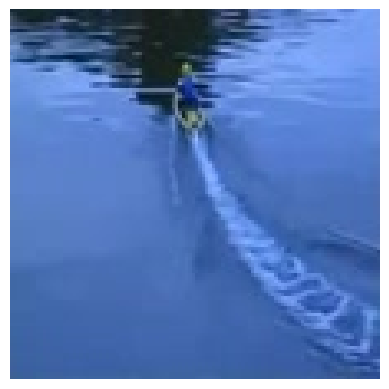

In [12]:
from PIL import Image
import matplotlib.pyplot as plt

img_path = os.path.join(output_frames_dir, frames[0])
img = Image.open(img_path)

plt.imshow(img)
plt.axis('off')

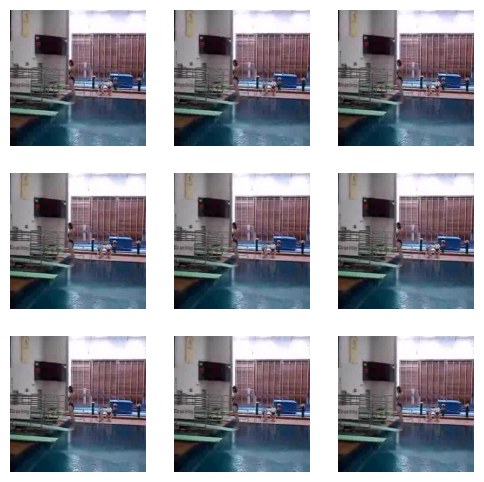

In [13]:
plt.figure(figsize=(6, 6))

for i in range(9):
  img = Image.open(os.path.join(output_frames_dir, frames[i]))
  plt.subplot(3, 3, i+1)
  plt.imshow(img)
  plt.axis('off')

In [14]:
def find_classes(directory):
    classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())
    if not classes:
        raise FileNotFoundError(f"Couldn't find any class folders in {directory}.")
    classes_to_idx = {cls_name : i for i , cls_name in enumerate(classes)}

    return classes, classes_to_idx

In [15]:
import torchvision

In [16]:
weights = torchvision.models.video.R3D_18_Weights.DEFAULT
weights

R3D_18_Weights.KINETICS400_V1

In [17]:
transforms = weights.transforms()
transforms

VideoClassification(
    crop_size=[112, 112]
    resize_size=[128, 171]
    mean=[0.43216, 0.394666, 0.37645]
    std=[0.22803, 0.22145, 0.216989]
    interpolation=InterpolationMode.BILINEAR
)